In [14]:
import os
import numpy as np
import cv2  # OpenCV for image loading
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Define paths for the dataset
train_dir = 'data/COMPOSITE/train'  # Path to the training images
test_dir = 'data/COMPOSITE/test'    # Path to the testing images

# Function to load images and compute mean pixel values
def load_images_and_compute_mean(directory):
    means = []
    labels = []
    filepaths = []
    for label, class_name in enumerate(['0', '1']):  # Assume 'defects' are positive class (1)
        class_dir = os.path.join(directory, class_name)
        for filename in os.listdir(class_dir):
            img_path = os.path.join(class_dir, filename)
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)  # Load the image in grayscale (16-bit)
            if img is not None:
                mean_value = np.mean(img)
                means.append(mean_value)
                labels.append(label)
                filepaths.append(img_path)
    return np.array(means).reshape(-1, 1), np.array(labels), filepaths

# Load training and test data
X_train, y_train, _ = load_images_and_compute_mean(train_dir)
X_test, y_test, test_filepaths = load_images_and_compute_mean(test_dir)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=3)  # Adjust k (n_neighbors) as needed
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Classification report and confusion matrix
print("Classification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))



Classification report:
              precision    recall  f1-score   support

           0       0.54      0.70      0.61        10
           1       0.57      0.40      0.47        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.54        20
weighted avg       0.55      0.55      0.54        20

Confusion matrix:
[[7 3]
 [6 4]]


False Positives (Count: 3):


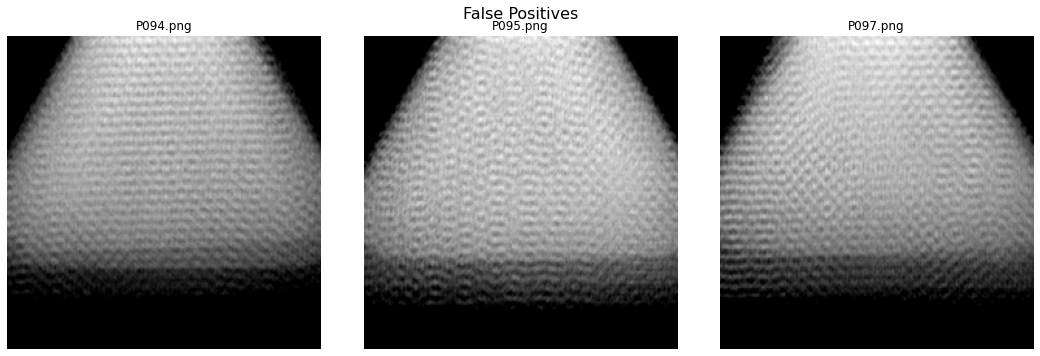

False Negatives (Count: 6):


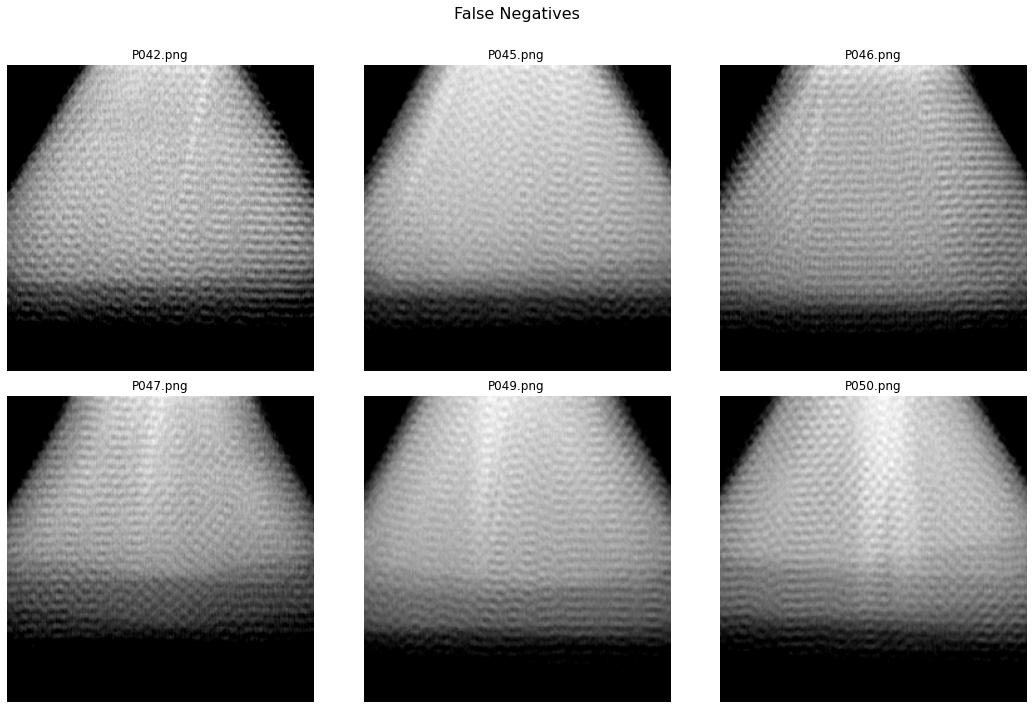

In [15]:
# Identify False Positives and False Negatives
false_positives = [test_filepaths[i] for i in range(len(y_test)) if y_pred[i] == 1 and y_test[i] == 0]
false_negatives = [test_filepaths[i] for i in range(len(y_test)) if y_pred[i] == 0 and y_test[i] == 1]

# Function to display images
def display_images(image_paths, title, n_cols=3):
    n_images = len(image_paths)
    n_rows = (n_images + n_cols - 1) // n_cols  # Calculate number of rows needed
    plt.figure(figsize=(15, n_rows * 5))
    plt.suptitle(title, fontsize=16)

    for i, img_path in enumerate(image_paths):
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)  # Load the 16-bit image
#         print(img.shape[:],np.max(img))
        img = img.astype(np.float32) / np.max(img)  # Scale to [0, 1]
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img, cmap='gray')  # Show as grayscale
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Adjust title position
    plt.show()

# Display False Positives
if false_positives:
    print(f"False Positives (Count: {len(false_positives)}):")
    display_images(false_positives, "False Positives")

# Display False Negatives
if false_negatives:
    print(f"False Negatives (Count: {len(false_negatives)}):")
    display_images(false_negatives, "False Negatives")